In [19]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance


In [20]:
df = pd.read_csv("nt_crime_merged.csv")

mapping = {
    "01 Homicide": "homicide",
    "02 Assault": "assault",
    "03 Sexual offences": "sexual",
    "04 Harm or endanger persons": "harm_endanger",
    "05 Robbery, blackmail, and extortion": "robbery_extortion",
    "061 Burglary - dwelling": "burglary_dwelling",
    "062 Burglary - non-residential": "burglary_nonres",
    "07 Theft": "theft",
    "11 Property damage offences": "property_damage"
}

mapping_type = {
    "0110 Murder": "murder",
    "0131 Manslaughter": "manslaughter",
    "0132 Driving causing death": "driving_causing_death",

    "021 Serious Assault": "serious_assault",
    "022 Assault of a prescribed officer": "assault_officer",
    "023 Common Assault": "common_assault",

    "031 Sexual assault of an adult": "sexual_adult",
    "032 Sexual assault of a child": "sexual_child",
    "033, 034 Other child-related sexual offences": "sexual_child_other",
    "035, 039 Other sexual offences": "sexual_other",

    "041, 042, 043 Human trafficking, abduction, deprivation of liberty": "human_trafficking_abduction",
    "044 Acts that threaten, harass or control": "threaten_harass_control",
    "049 Other acts that harm or endanger persons": "harm_endanger_other",
    "045 Driving causing serious injury": "driving_serious_injury",

    "051 Robbery": "robbery",
    "052 Blackmail or other extortion": "extortion",

    "061 Burglary - dweling (house break-ins), attempted": "burglary_dwelling_attempted",
    "061 Burglary - dwelling (house break-ins), actual": "burglary_dwelling_actual",
    "062 Burglary - non-residential (commercial break-ins), actual": "burglary_nonres_actual",
    "062 Burglary - non-residential (commercial break-ins), attempted": "burglary_nonres_attempted",

    "07* Other theft": "theft_other",
    "071 Motor vehicle theft and related offences": "theft_vehicle",

    "11 Property damage offences": "property_damage"
}


df["Offence type"] = df["Offence type"].map(mapping_type)
df['Offence category'] = df['Offence category'].map(mapping)
df["Offence type"].unique()
df = pd.get_dummies(df, columns=['Offence category', 'Offence type'], prefix = 'off')
df.drop(columns = ['Region'], inplace=True)

df.columns
df_assault = df[df['off_assault'] == True]

# df_assault.to_csv("thomas_processed.csv")

# Sum DV / alcohol involvement flags
region_cols = [col for col in df.columns if col.startswith('Region_')]
df['region'] = df[region_cols].idxmax(axis=1).str.replace('Region_', '')

agg_dict = {}

for col in df.columns:
    if col in ['region', 'Year', 'Month number']:
        continue

    # SUM columns that should be aggregated
    elif col in ['Number of offences', 'Alcohol involvement', 'DV involvement']:
        agg_dict[col] = 'sum'

    # Everything else: keep first value (already aggregated stats)
    elif col.__contains__("PAC") or col.startswith("Pop") or col in ["Total_population", "Aboriginal", "Non-Aboriginal", "Male", "Female"]:
        agg_dict[col] = 'first'
    
    
df = (
    df.groupby(['region', 'Year', 'Month number'])
      .agg(agg_dict)
      .reset_index()
)
df
df["assault_rate"] = df["Number of offences"] / df["Total_population"] * 1000
df.columns 
# df_region_month.to_csv("thomas_processed.csv")

#Cyclic month encoding
df['sin_month'] = np.sin(2 * np.pi * df['Month number'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['Month number'] / 12)

#Demographic proportion
df['pct_aboriginal'] = df['Aboriginal'] / df['Total_population']
df['pct_male'] = df['Male'] / df['Total_population']
df['pct_youth'] = (df['Pop_age_15'] + df['Pop_age_20']) / df['Total_population']
df['pct_senior'] = (
    df['Pop_age_65'] + df['Pop_age_70'] + df['Pop_age_75'] +
    df['Pop_age_80'] + df['Pop_age_85plus']
) / df['Total_population']

#Normalise PAC values
df['alcohol_per_capita'] = df['Total PAC'] / df['Total_population']
df['beer_per_capita'] = (
    df['Full-Strength Beer PAC'] +
    df['Mid-Strength Beer PAC'] +
    df['Low-Strength Beer PAC']
) / df['Total_population']
df['wine_per_capita'] = (
    df['Cask Wine PAC'] +
    df['Bottled Wine PAC'] +
    df['Fortified Wine PAC']
) / df['Total_population']

#adding lag
df['assault_rate_lag1'] = df.groupby('region')['assault_rate'].shift(1)
df['assault_rate_lag3'] = df.groupby('region')['assault_rate'].shift(3)

df.to_csv("thomas_processed.csv")



Research question 2 - Predicts monthly assult rates for each NT region using past crime data, population characteristics and alcohol supply volume


RMSE: 21.62323412287793
MAE: 10.55073953029997
MAPE: 45.867754922900716


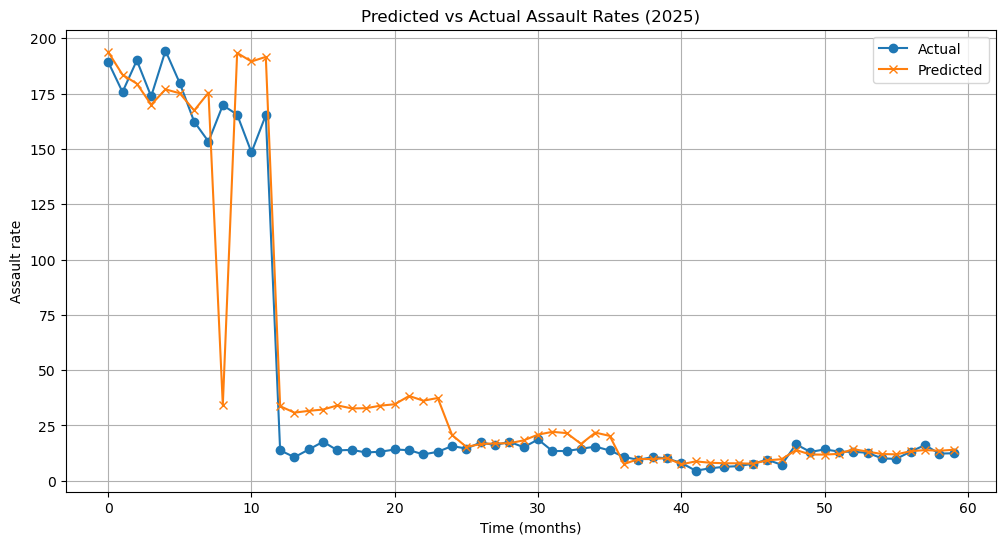

In [ ]:


# Ensure proper ordering
df = df.sort_values(['region', 'Year', 'Month number'])


# Drop rows where lag features are missing
df = df.dropna(subset=['assault_rate_lag1', 'assault_rate_lag3'])

# --- Train/test split ---
train = df[df['Year'] == 2024]
test  = df[df['Year'] == 2025]


feature_cols = [
    # Time features
     "sin_month",
    "cos_month",
    "Alcohol involvement",
    "alcohol_per_capita",
    "pct_youth",
    "pct_male"
]

# Train = 2024, Test = 2025
train = df[df['Year'] == 2024]
test  = df[df['Year'] == 2025]

X_train = train[feature_cols]
y_train = train['assault_rate']

X_test = test[feature_cols]
y_test = test['assault_rate']


model_xg = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    random_state=42
)

model_xg.fit(X_train, y_train)

pred = model_xg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

plt.figure(figsize=(12,6))
plt.plot(test['assault_rate'].values, label='Actual', marker='o')
plt.plot(pred, label='Predicted', marker='x')
plt.title('Predicted vs Actual Assault Rates (2025)')
plt.xlabel('Time (months)')
plt.ylabel('Assault rate')
plt.legend()
plt.grid(True)
plt.show()


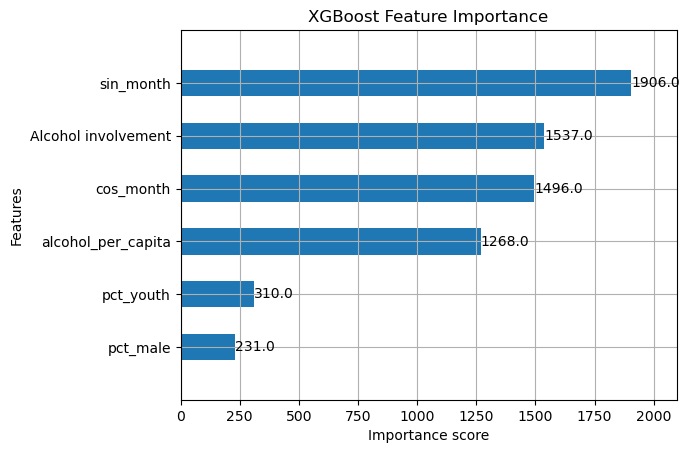

: 

In [ ]:

xgb.plot_importance(model_xg, max_num_features=20, height=0.5)
plt.title("XGBoost Feature Importance")
plt.show()

In [23]:
df.columns

Index(['region', 'Year', 'Month number', 'Alcohol involvement',
       'DV involvement', 'Total_population', 'Aboriginal', 'Non-Aboriginal',
       'Male', 'Female', 'Pop_age_0', 'Pop_age_10', 'Pop_age_15', 'Pop_age_20',
       'Pop_age_25', 'Pop_age_30', 'Pop_age_35', 'Pop_age_40', 'Pop_age_45',
       'Pop_age_5', 'Pop_age_50', 'Pop_age_55', 'Pop_age_60', 'Pop_age_65',
       'Pop_age_70', 'Pop_age_75', 'Pop_age_80', 'Pop_age_85plus',
       'Cask Wine PAC', 'Bottled Wine PAC', 'Fortified Wine PAC', 'Cider PAC',
       'Standard Spirits PAC', 'Mixed Spirits PAC', 'Full-Strength Beer PAC',
       'Mid-Strength Beer PAC', 'Low-Strength Beer PAC', 'Total PAC',
       'Number of offences', 'assault_rate', 'sin_month', 'cos_month',
       'pct_aboriginal', 'pct_male', 'pct_youth', 'pct_senior',
       'alcohol_per_capita', 'beer_per_capita', 'wine_per_capita',
       'assault_rate_lag1', 'assault_rate_lag3'],
      dtype='object')

In [40]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor




features = [
    "sin_month",
    "cos_month",
    "assault_rate_lag1",
    "Alcohol involvement",
    "alcohol_per_capita",
    "pct_youth",
    "pct_male"

]

# --- 1. Drop rows with NaN in any baseline feature ---
df_clean = df.dropna(subset=[
    "assault_rate_lag1",
    "assault_rate_lag3",
    "assault_rate"
]).copy()

train = df_clean[df_clean["Year"] == 2024]
test  = df_clean[df_clean["Year"] == 2025]



train = df_clean[df_clean["Year"] == 2024]
test  = df_clean[df_clean["Year"] == 2025]
print(train.shape, test.shape)

X_train = train[features]
y_train = train["assault_rate"]


X = sm.add_constant(X_train)

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)
X_test = test[features]
y_test = test["assault_rate"]
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)
model_lin = sm.OLS(y_train, X_train_sm).fit()


preds = model_lin.predict(X_test_sm)
rmse = root_mean_squared_error(y_test, preds)

print("Test RMSE:", rmse)


(45, 51) (60, 51)
               feature           VIF
0                const  22039.321917
1            sin_month      1.133466
2            cos_month      1.115678
3    assault_rate_lag1      9.294522
4  Alcohol involvement     11.595756
5   alcohol_per_capita      1.803706
6            pct_youth      4.841280
7             pct_male      4.567682
Test RMSE: 6.972886013140579


Hypothesis Testing

In [35]:
model_lin.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           assault_rate   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     749.2
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           8.01e-37
Time:                        11:04:01   Log-Likelihood:                -131.60
No. Observations:                  45   AIC:                             285.2
Df Residuals:                      34   BIC:                             305.1
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -3166.1058    398.957     -7.936      0.000   -3976.885   -2355.327
sin_month              -5.8793      1.469     -4.002      0.000      -8.865      -2.894
cos_month               6.1025      1.611      3.789      0.001       2.829       9.376
assault_rate_lag3      -0.1114      0.130     -0.858      0.397      -0.375       0.152
Alcohol involvement     3.4068      1.315      2.590      0.014       0.734       6.080
DV involvement         -4.1074      1.502     -2.735      0.010      -7.160      -1.055
beer_per_capita       -92.4553     11.656     -7.932      0.000    -116.143     -68.768
wine_per_capita       223.2046     36.150      6.174      0.000     149.740     296.669
pct_aboriginal       1204.5733    141.732      8.499      0.000     916.539    1492.607
pct_male             7532.2469    942.069      7.995      0.000    5617.733    9446.760
pct_youth           -8074.9582    964.566     -8.372      0.000      -1e+04   -6114.724
==============================================================================
Omnibus:                        0.109   Durbin-Watson:                   1.810
Prob(Omnibus):                  0.947   Jarque-Bera (JB):                0.314
Skew:                          -0.044   Prob(JB):                        0.855
Kurtosis:                       2.601   Cond. No.                     1.51e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:

result = permutation_importance(
    model_xg, X_test, y_test, n_repeats=30, random_state=42
)

importances = result.importances_mean
stds = result.importances_std

for feat, imp, std in zip(X_test.columns, importances, stds):
    print(f"{feat}: mean={imp:.4f}, std={std:.4f}")

sin_month: mean=0.0043, std=0.0030
cos_month: mean=0.0034, std=0.0029
assault_rate_lag1: mean=1.1294, std=0.1632
assault_rate_lag3: mean=0.0713, std=0.0229
Total_population: mean=0.0050, std=0.0017
Alcohol involvement: mean=0.0001, std=0.0002
DV involvement: mean=0.0006, std=0.0006
Total PAC: mean=0.0046, std=0.0043
alcohol_per_capita: mean=-0.0000, std=0.0004
beer_per_capita: mean=0.0032, std=0.0015
wine_per_capita: mean=0.0001, std=0.0001
pct_aboriginal: mean=0.0002, std=0.0001
pct_male: mean=0.0001, std=0.0001
pct_youth: mean=-0.0000, std=0.0000
pct_senior: mean=0.0000, std=0.0000
